# 04 Machine Learning Models

In this notebook, we train classical machine learning models for wearable stress detection.

We use the feature dataset created in Notebook 03. Each row represents one 30-second physiological signal window, and each column represents an extracted feature from ECG, EDA, respiration, or temperature.

The goal is to classify each window into one of three classes:

- Neutral / Baseline
- Stress
- Amusement

In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed data folder:", PROCESSED_DATA_DIR)
print("Results folder:", RESULTS_DIR)
print("Models folder:", MODELS_DIR)

print("Feature file exists:", (PROCESSED_DATA_DIR / "features.csv").exists())

Processed data folder: ..\data\processed
Results folder: ..\results
Models folder: ..\models
Feature file exists: True


In [3]:
features_path = PROCESSED_DATA_DIR / "features.csv"

features_df = pd.read_csv(features_path)

print("Feature dataset shape:", features_df.shape)

features_df.head()

Feature dataset shape: (2151, 75)


,subject_id,window_id,start_sec,end_sec,majority_ratio,ECG_mean,ECG_std,ECG_min,ECG_max,ECG_median,...,Temp_rms,Temp_energy,Temp_mean_abs_change,Temp_std_change,Temp_max_abs_change,Temp_zero_crossings,Temp_skewness,Temp_kurtosis,label,label_name
0,S10,0,90.0,120.0,0.904762,0.001516,0.132416,-0.663895,0.785843,0.030716,...,33.897731,1149.056162,0.022942,0.032233,0.183929,0,-0.302280,3.753279,1,Neutral / Baseline
1,S10,1,105.0,135.0,1.000000,0.000542,0.136359,-0.574814,0.821457,0.031586,...,33.922503,1150.736193,0.024211,0.033127,0.177979,0,-0.395398,4.197550,1,Neutral / Baseline
2,S10,2,120.0,150.0,1.000000,0.001889,0.140376,-0.667923,0.821457,0.028976,...,33.949085,1152.540389,0.024425,0.033431,0.177979,0,-0.298644,3.715316,1,Neutral / Baseline
3,S10,3,135.0,165.0,1.000000,0.001967,0.154921,-0.667923,0.838211,0.019730,...,33.982891,1154.836868,0.024582,0.033548,0.179626,0,-0.029038,3.213001,1,Neutral / Baseline
4,S10,4,150.0,180.0,1.000000,0.000855,0.161409,-0.664948,0.838211,0.005791,...,34.028476,1157.937208,0.026112,0.035063,0.179871,0,-0.213312,2.793012,1,Neutral / Baseline


In [4]:
print("Columns in feature dataset:")

for column in features_df.columns:
    print(column)

Columns in feature dataset:
subject_id
window_id
start_sec
end_sec
majority_ratio
ECG_mean
ECG_std
ECG_min
ECG_max
ECG_median
ECG_range
ECG_q25
ECG_q75
ECG_iqr
ECG_rms
ECG_energy
ECG_mean_abs_change
ECG_std_change
ECG_max_abs_change
ECG_zero_crossings
ECG_skewness
ECG_kurtosis
EDA_mean
EDA_std
EDA_min
EDA_max
EDA_median
EDA_range
EDA_q25
EDA_q75
EDA_iqr
EDA_rms
EDA_energy
EDA_mean_abs_change
EDA_std_change
EDA_max_abs_change
EDA_zero_crossings
EDA_skewness
EDA_kurtosis
Resp_mean
Resp_std
Resp_min
Resp_max
Resp_median
Resp_range
Resp_q25
Resp_q75
Resp_iqr
Resp_rms
Resp_energy
Resp_mean_abs_change
Resp_std_change
Resp_max_abs_change
Resp_zero_crossings
Resp_skewness
Resp_kurtosis
Temp_mean
Temp_std
Temp_min
Temp_max
Temp_median
Temp_range
Temp_q25
Temp_q75
Temp_iqr
Temp_rms
Temp_energy
Temp_mean_abs_change
Temp_std_change
Temp_max_abs_change
Temp_zero_crossings
Temp_skewness
Temp_kurtosis
label
label_name


In [5]:
class_distribution = features_df["label_name"].value_counts().reset_index()
class_distribution.columns = ["label_name", "window_count"]

class_distribution

,label_name,window_count
0,Neutral / Baseline,1154
1,Stress,644
2,Amusement,353


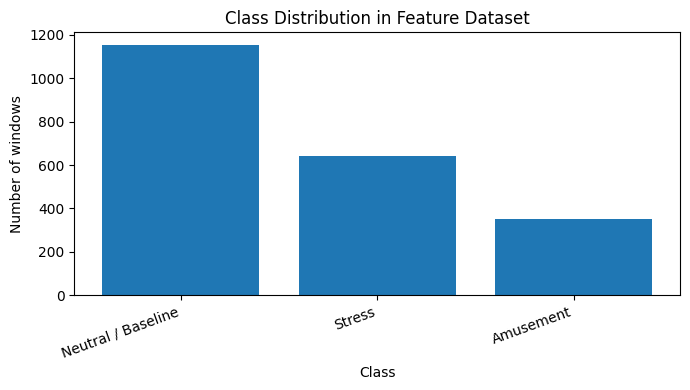

Saved figure to: ..\results\ml_class_distribution.png


In [6]:
plt.figure(figsize=(7, 4))
plt.bar(class_distribution["label_name"], class_distribution["window_count"])
plt.xlabel("Class")
plt.ylabel("Number of windows")
plt.title("Class Distribution in Feature Dataset")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "ml_class_distribution.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [7]:
metadata_columns = [
    "subject_id",
    "window_id",
    "start_sec",
    "end_sec",
    "majority_ratio",
    "label",
    "label_name"
]

feature_columns = [column for column in features_df.columns if column not in metadata_columns]

X = features_df[feature_columns]
y = features_df["label"]
groups = features_df["subject_id"]

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Target shape:", y.shape)
print("Number of subjects:", groups.nunique())

Number of samples: 2151
Number of features: 68
Target shape: (2151,)
Number of subjects: 15


In [8]:
print("First 20 feature columns:")

for column in feature_columns[:20]:
    print(column)

First 20 feature columns:
ECG_mean
ECG_std
ECG_min
ECG_max
ECG_median
ECG_range
ECG_q25
ECG_q75
ECG_iqr
ECG_rms
ECG_energy
ECG_mean_abs_change
ECG_std_change
ECG_max_abs_change
ECG_zero_crossings
ECG_skewness
ECG_kurtosis
EDA_mean
EDA_std
EDA_min


In [9]:
missing_values = X.isnull().sum()
missing_values = missing_values[missing_values > 0]

missing_values

Series([], dtype: int64)

In [10]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_index]
X_test = X.iloc[test_index]

y_train = y.iloc[train_index]
y_test = y.iloc[test_index]

groups_train = groups.iloc[train_index]
groups_test = groups.iloc[test_index]

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("Training subjects:", sorted(groups_train.unique()))
print("Testing subjects:", sorted(groups_test.unique()))

Training samples: 1718
Testing samples: 433
Training subjects: ['S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S5', 'S7', 'S8', 'S9']
Testing subjects: ['S10', 'S4', 'S6']


In [11]:
train_subjects = set(groups_train.unique())
test_subjects = set(groups_test.unique())

overlap_subjects = train_subjects.intersection(test_subjects)

print("Overlapping subjects:", overlap_subjects)

Overlapping subjects: set()


In [12]:
train_distribution = y_train.map({
    1: "Neutral / Baseline",
    2: "Stress",
    3: "Amusement"
}).value_counts()

test_distribution = y_test.map({
    1: "Neutral / Baseline",
    2: "Stress",
    3: "Amusement"
}).value_counts()

print("Training class distribution:")
print(train_distribution)

print("\nTesting class distribution:")
print(test_distribution)

Training class distribution:
label
Neutral / Baseline    923
Stress                514
Amusement             281
Name: count, dtype: int64

Testing class distribution:
label
Neutral / Baseline    231
Stress                130
Amusement              72
Name: count, dtype: int64


In [13]:
LABEL_NAMES = {
    1: "Neutral / Baseline",
    2: "Stress",
    3: "Amusement"
}

CLASS_LABELS = [1, 2, 3]
CLASS_NAMES = [LABEL_NAMES[label] for label in CLASS_LABELS]

print(CLASS_NAMES)

['Neutral / Baseline', 'Stress', 'Amusement']


In [14]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    
    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", GradientBoostingClassifier(
            random_state=42
        ))
    ])
}

print("Models defined:")

for model_name in models.keys():
    print("-", model_name)

Models defined:
- Logistic Regression
- Random Forest
- Support Vector Machine
- Gradient Boosting


In [15]:
results = []
trained_models = {}

for model_name, model in models.items():
    print("=" * 60)
    print("Training model:", model_name)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    
    results.append({
        "model": model_name,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1
    })
    
    trained_models[model_name] = model
    
    print("Accuracy:", round(accuracy, 4))
    print("Macro Precision:", round(macro_precision, 4))
    print("Macro Recall:", round(macro_recall, 4))
    print("Macro F1:", round(macro_f1, 4))

Training model: Logistic Regression
Accuracy: 0.5797
Macro Precision: 0.5497
Macro Recall: 0.5719
Macro F1: 0.5498
Training model: Random Forest
Accuracy: 0.612
Macro Precision: 0.5499
Macro Recall: 0.4338
Macro F1: 0.4136
Training model: Support Vector Machine
Accuracy: 0.5242
Macro Precision: 0.498
Macro Recall: 0.5016
Macro F1: 0.4839
Training model: Gradient Boosting
Accuracy: 0.7067
Macro Precision: 0.6761
Macro Recall: 0.5603
Macro F1: 0.5775


In [16]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="macro_f1", ascending=False)

results_df

,model,accuracy,macro_precision,macro_recall,macro_f1
3,Gradient Boosting,0.706697,0.676092,0.560341,0.577475
0,Logistic Regression,0.579677,0.549678,0.571852,0.549797
2,Support Vector Machine,0.524249,0.497962,0.501576,0.483924
1,Random Forest,0.612009,0.549927,0.433789,0.413570


In [17]:
model_results_path = RESULTS_DIR / "ml_model_comparison.csv"

results_df.to_csv(model_results_path, index=False)

print("Saved model comparison results to:", model_results_path)

Saved model comparison results to: ..\results\ml_model_comparison.csv


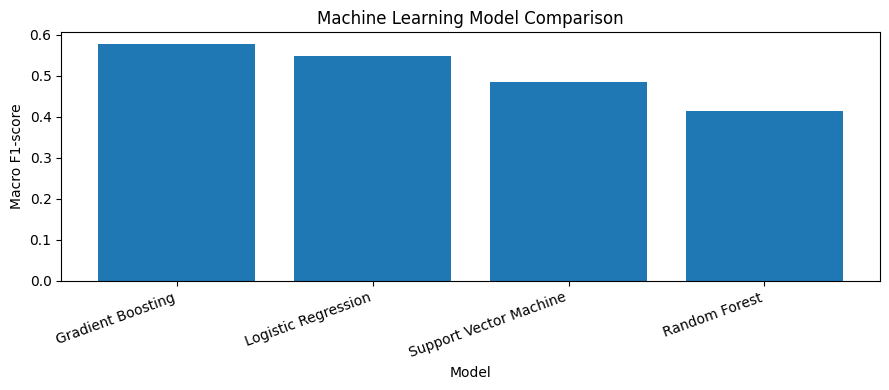

Saved figure to: ..\results\ml_model_comparison_macro_f1.png


In [18]:
plt.figure(figsize=(9, 4))
plt.bar(results_df["model"], results_df["macro_f1"])
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.title("Machine Learning Model Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "ml_model_comparison_macro_f1.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved figure to:", output_path)

In [19]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

Best model: Gradient Boosting


In [20]:
best_y_pred = best_model.predict(X_test)

report = classification_report(
    y_test,
    best_y_pred,
    labels=CLASS_LABELS,
    target_names=CLASS_NAMES,
    zero_division=0
)

print(report)

                    precision    recall  f1-score   support

Neutral / Baseline       0.69      0.97      0.80       231
            Stress       0.97      0.53      0.69       130
         Amusement       0.37      0.18      0.24        72

          accuracy                           0.71       433
         macro avg       0.68      0.56      0.58       433
      weighted avg       0.72      0.71      0.67       433



In [21]:
classification_report_path = RESULTS_DIR / "best_ml_classification_report.txt"

with open(classification_report_path, "w") as file:
    file.write(f"Best model: {best_model_name}\n\n")
    file.write(report)

print("Saved classification report to:", classification_report_path)

Saved classification report to: ..\results\best_ml_classification_report.txt


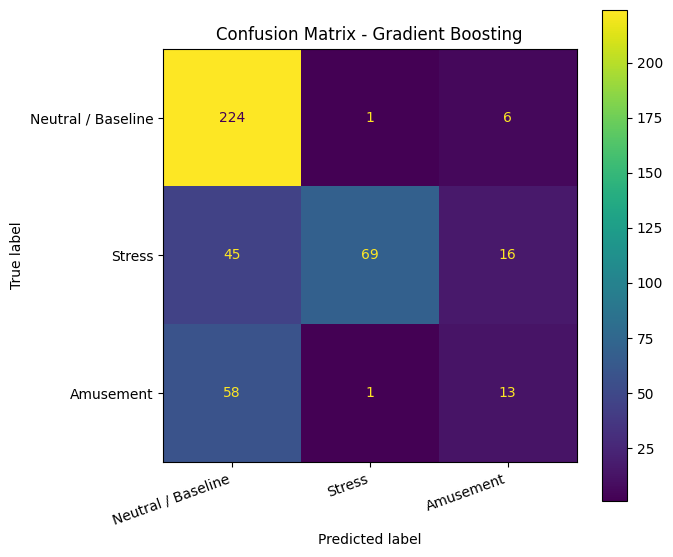

Saved confusion matrix to: ..\results\best_ml_confusion_matrix.png


In [22]:
cm = confusion_matrix(
    y_test,
    best_y_pred,
    labels=CLASS_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

output_path = RESULTS_DIR / "best_ml_confusion_matrix.png"
plt.savefig(output_path, dpi=300)
plt.show()

print("Saved confusion matrix to:", output_path)

In [23]:
best_model_path = MODELS_DIR / "best_ml_model.pkl"

with open(best_model_path, "wb") as file:
    pickle.dump(best_model, file)

print("Saved best model locally to:", best_model_path)

Saved best model locally to: ..\models\best_ml_model.pkl


In [24]:
feature_columns_path = MODELS_DIR / "feature_columns.pkl"

with open(feature_columns_path, "wb") as file:
    pickle.dump(feature_columns, file)

print("Saved feature columns locally to:", feature_columns_path)

Saved feature columns locally to: ..\models\feature_columns.pkl


In [25]:
example_test_index = 0

single_sample = X_test.iloc[[example_test_index]]
true_label = y_test.iloc[example_test_index]

predicted_label = best_model.predict(single_sample)[0]

print("True label:", true_label, "-", LABEL_NAMES[true_label])
print("Predicted label:", predicted_label, "-", LABEL_NAMES[predicted_label])

True label: 1 - Neutral / Baseline
Predicted label: 1 - Neutral / Baseline


In [27]:
if hasattr(best_model, "predict_proba"):
    probabilities = best_model.predict_proba(single_sample)[0]
    
    probability_df = pd.DataFrame({
        "class": CLASS_NAMES,
        "probability": probabilities
    })
    
    probability_df
else:
    print("This model does not support probability prediction.")

In [28]:
ml_summary_rows = []

ml_summary_rows.append({
    "item": "training_samples",
    "value": X_train.shape[0]
})

ml_summary_rows.append({
    "item": "testing_samples",
    "value": X_test.shape[0]
})

ml_summary_rows.append({
    "item": "number_of_features",
    "value": X_train.shape[1]
})

ml_summary_rows.append({
    "item": "training_subjects",
    "value": ", ".join(sorted(groups_train.unique()))
})

ml_summary_rows.append({
    "item": "testing_subjects",
    "value": ", ".join(sorted(groups_test.unique()))
})

ml_summary_rows.append({
    "item": "best_model",
    "value": best_model_name
})

best_result_row = results_df.iloc[0]

ml_summary_rows.append({
    "item": "best_accuracy",
    "value": best_result_row["accuracy"]
})

ml_summary_rows.append({
    "item": "best_macro_f1",
    "value": best_result_row["macro_f1"]
})

ml_summary_df = pd.DataFrame(ml_summary_rows)

ml_summary_path = RESULTS_DIR / "ml_summary.csv"
ml_summary_df.to_csv(ml_summary_path, index=False)

ml_summary_df

,item,value
0,training_samples,1718
1,testing_samples,433
2,number_of_features,68
3,training_subjects,"S11, S13, S14, S15, S16, S17, S2, S3, S5, S7, ..."
4,testing_subjects,"S10, S4, S6"
5,best_model,Gradient Boosting
6,best_accuracy,0.706697
7,best_macro_f1,0.577475


In [29]:
print("Result files:")

for file_path in sorted(RESULTS_DIR.iterdir()):
    if file_path.name.startswith("ml") or file_path.name.startswith("best_ml"):
        print(file_path.name)

Result files:
best_ml_classification_report.txt
best_ml_confusion_matrix.png
ml_class_distribution.png
ml_model_comparison.csv
ml_model_comparison_macro_f1.png
ml_summary.csv
